<a href="https://colab.research.google.com/github/Rame395/Machine-Learning/blob/main/Data_Preprocessing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Data Preprocessing**

Data preprocessing is the first step in any machine learning pipeling that involves cleaning, transfroming and orgainizing raw data to ensure it is accurate, consistent and ready for modeling

Step 1: Import Libraries and Load Dataset

In [22]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [11]:
df = pd.read_csv('/content/diabetes.csv')
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


Step 2: Inspect Data Structure and Check Missing Values

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [4]:
df.isnull().sum()

,0
Pregnancies,0
Glucose,0
BloodPressure,0
SkinThickness,0
Insulin,0
BMI,0
DiabetesPedigreeFunction,0
Age,0
Outcome,0


Step 3: Statistical Summary and Visualizing Outline

In [5]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


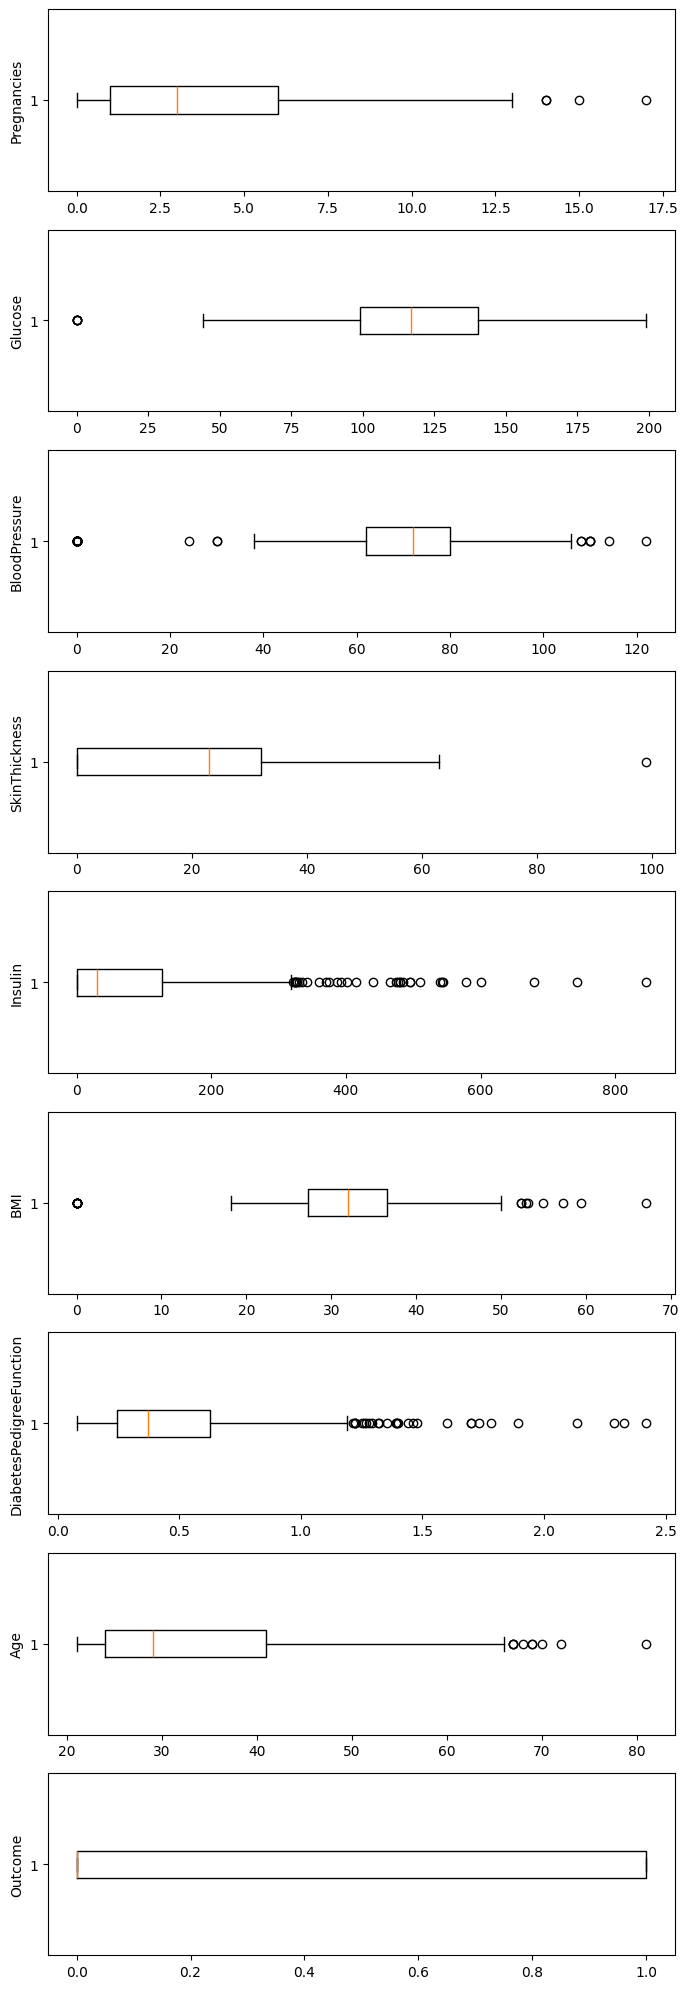

In [5]:
fig, axs = plt.subplots(len(df.columns), 1, figsize=(7,20))
for i, col in enumerate(df.columns):
  axs[i].boxplot(df[col], vert=False)
  axs[i].set_ylabel(col)
plt.tight_layout()
plt.show()

In [21]:
q1, q3 = np.percentile(df['Insulin'], [25, 75])
iqr = q3 -q1
lower_bound = q1 - 1.5 *iqr
upper_bound = q3 + 1.5 *iqr

filtered_df = df[(df['Insulin']>=lower_bound) & (df['Insulin']<=upper_bound)]



In [12]:
df2=df.copy()

In [13]:
len(df2)

768

In [14]:
for col in df2.columns:
  if df2[col].dtype!='object':
    q1, q3 = np.percentile(df2[col], [25,75])
    iqr = q3 - q1
    lower_bound = q1-1.5*iqr
    upper_bound = q3+1.5*iqr

    # df2 = [(df2[col]>=lower_bound) & (df2[col]<=upper_bound)]
    df2[col] = np.clip(df2[col], lower_bound, upper_bound)

In [15]:
len(df2)

768

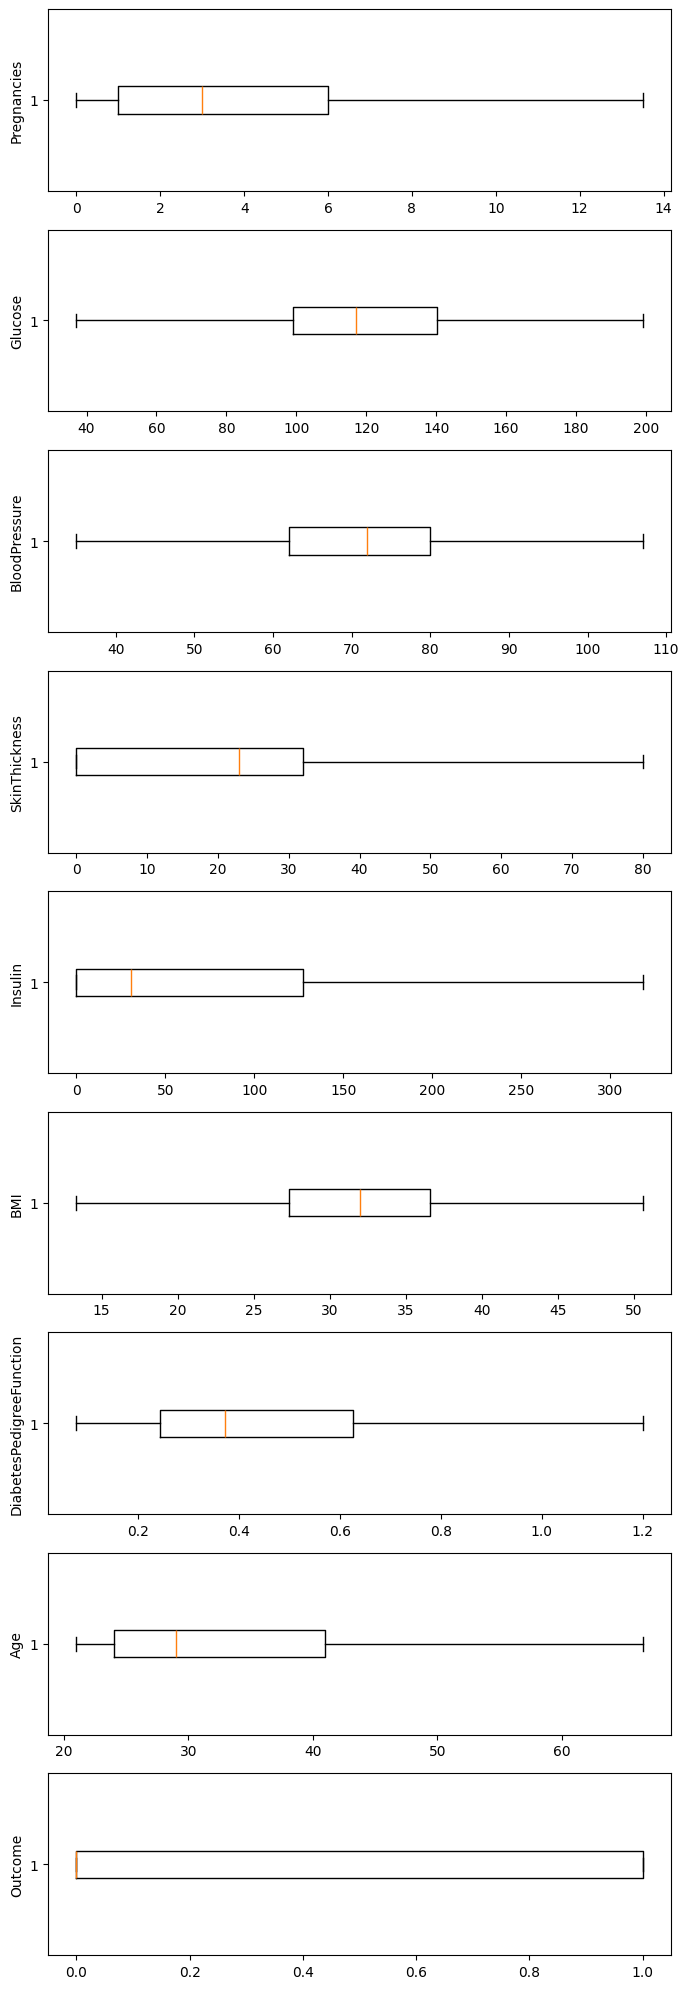

In [17]:
fig, axs = plt.subplots(len(df2.columns), 1, figsize=(7,20))
for i, col in enumerate(df2.columns):
  axs[i].boxplot(df2[col],vert=False)
  axs[i].set_ylabel(col)
plt.tight_layout()
plt.show()

In [18]:
# Print the statistical summary before and after clipping
print("--- BEFORE CLIPPING ---")
print(df['Insulin'].describe())

print("\n--- AFTER CLIPPING ---")
print(df2['Insulin'].describe())


--- BEFORE CLIPPING ---
count    768.000000
mean      79.799479
std      115.244002
min        0.000000
25%        0.000000
50%       30.500000
75%      127.250000
max      846.000000
Name: Insulin, dtype: float64

--- AFTER CLIPPING ---
count    768.000000
mean      73.652669
std       93.576029
min        0.000000
25%        0.000000
50%       30.500000
75%      127.250000
max      318.125000
Name: Insulin, dtype: float64


In [20]:
df_skew = df['Insulin'].skew()
df2_skew = df2['Insulin'].skew()

print(f"Original Dataset skewness score: {df_skew}")
print(f"After handling outliner skewness score: {df2_skew}")

Original Dataset skewness score: 2.272250858431574
After handling outliner skewness score: 1.1738981213083215


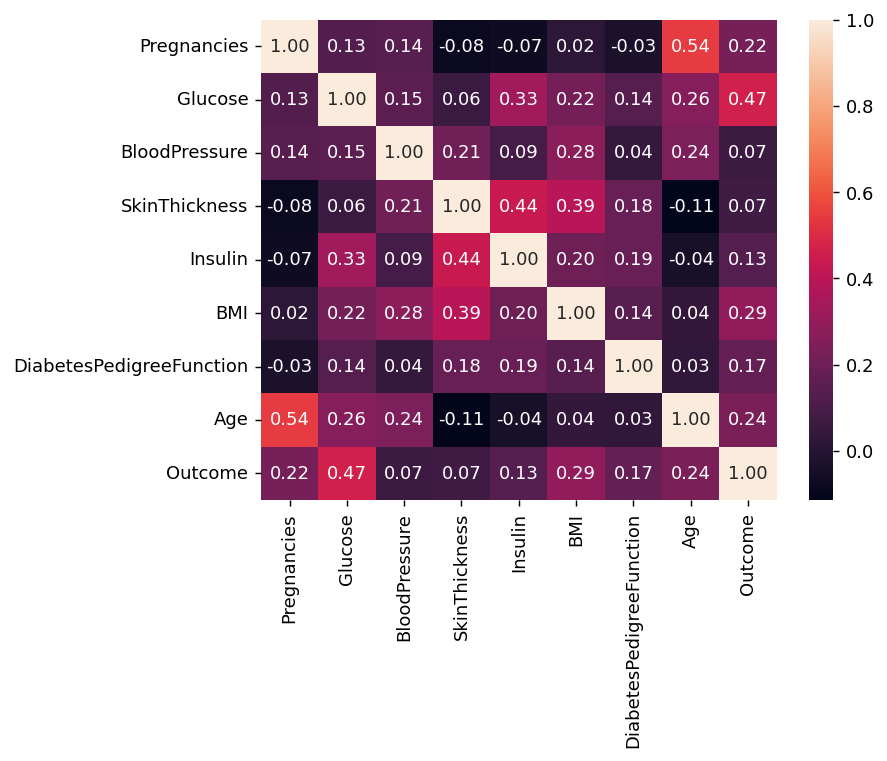

In [24]:
corr = df.corr()
plt.figure(dpi=130)
sns.heatmap(corr, annot=True, fmt='.2f')
plt.show()